# Eksploracyjna analiza danych (EDA) — Spotify Tracks Dataset

Autorzy: Julia Nowakowska, Sebastian Wróbel, Maciej Andrzejewski, Sławomir Stefański, Wojciech Kaczmarek

Zbiór danych: *Spotify Tracks Dataset* (Kaggle) — plik `data/dataset.csv`.

Cele EDA (wg wymagań z zajęć):
- określenie typów atrybutów,
- sprawdzenie rozkładów danych,
- wizualizacje: korelacje, boxploty, histogramy, inne pomocne wykresy,
- krótkie wnioski pod projekt (osobisty system rekomendacyjny).


### Importy bibliotek

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120})
np.random.seed(42)


### Wczytanie danych

In [22]:
df = pd.read_csv("data/dataset.csv")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Podstawowe informacje 
Zbiór danych zawiera informacje o utworach muzycznych wraz z ich cechami akustycznymi.
Większość atrybutów ma charakter numeryczny, co umożliwia bezpośrednią analizę statystyczną.

In [23]:
print("Informacje o zbiorze danych:")
df.info()

print("\nStatystyki opisowe:")
display(df.describe())

print("\nBraki danych:")
print(df.isnull().sum())

Informacje o zbiorze danych:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  li

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000



Braki danych:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


### Typy atrybutów (numeryczne vs kategoryczne)

W tej sekcji rozdzielamy cechy na:
- **numeryczne** (do korelacji / skalowania),
- **kategoryczne/tekstowe** (np. `artists`, `track_name`, `track_genre`)


In [24]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in df.columns if c not in numeric_cols]

print("Kolumny numeryczne (", len(numeric_cols), "): ", numeric_cols)
print("Kolumny kategoryczne/tekstowe (", len(cat_cols), "): ", cat_cols)

if cat_cols:
    display(
        pd.DataFrame(
            {
                "dtype": df[cat_cols].dtypes.astype(str),
                "n_unique": df[cat_cols].nunique(dropna=False),
                "example": [df[c].dropna().astype(str).head(1).iloc[0] if df[c].notna().any() else None for c in cat_cols],
            }
        ).sort_values("n_unique", ascending=False).head(20)
    )


Kolumny numeryczne ( 15 ):  ['Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Kolumny kategoryczne/tekstowe ( 6 ):  ['track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre']


,dtype,n_unique,example
track_id,str,89741,5SuOikwiRyPMVoIQDJUgSV
track_name,str,73609,Comedy
album_name,str,46590,Comedy
artists,str,31438,Gen Hoshino
track_genre,str,114,acoustic
explicit,bool,2,False


### Czyszczenie danych
Usunięto brakujące wartości oraz duplikaty, aby zapewnić spójność danych.

In [25]:
print("Rozmiar przed czyszczeniem:", df.shape)

duplicates = df.duplicated().sum()
print("Liczba duplikatów:", duplicates)

df = df.drop_duplicates()

print("Rozmiar po usunięciu duplikatów:", df.shape)

Rozmiar przed czyszczeniem: (114000, 21)
Liczba duplikatów: 0
Rozmiar po usunięciu duplikatów: (114000, 21)


### Wybór cech
Do analizy wybrano cechy opisujące właściwości audio utworów, istotne z punktu widzenia systemu rekomendacyjnego.

Do właściwej analizy oraz budowy systemu rekomendacyjnego wykorzystano wyłącznie cechy numeryczne opisujące właściwości audio utworów.
Dodatkowe kolumny, takie jak popularność czy gatunek, zostały użyte jedynie pomocniczo w analizie eksploracyjnej.

In [26]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]

extra_cols = [c for c in ["popularity", "duration_ms", "explicit", "track_genre"] if c in df.columns]

print("Wybrane cechy audio (do modelu):")
print(features)

display(df[features].head())

print("\nDodatkowe kolumny pomocnicze (EDA):")
print(extra_cols)

display(df[extra_cols].head())

Wybrane cechy audio (do modelu):
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949



Dodatkowe kolumny pomocnicze (EDA):
['popularity', 'duration_ms', 'explicit', 'track_genre']


,popularity,duration_ms,explicit,track_genre
0,73,230666,False,acoustic
1,55,149610,False,acoustic
2,57,210826,False,acoustic
3,71,201933,False,acoustic
4,82,198853,False,acoustic


### Histogramy

Histogramy pozwalają zobaczyć, jak rozkładają się wartości poszczególnych cech.

Aby wykresy były bardziej czytelne:
- ograniczono zakres osi X do wartości od 1 do 99 percentyla (żeby pominąć skrajne wartości),
- dla cech z zakresu [0, 1] ustawiono stały zakres osi,
- liczba przedziałów została dobrana automatycznie.

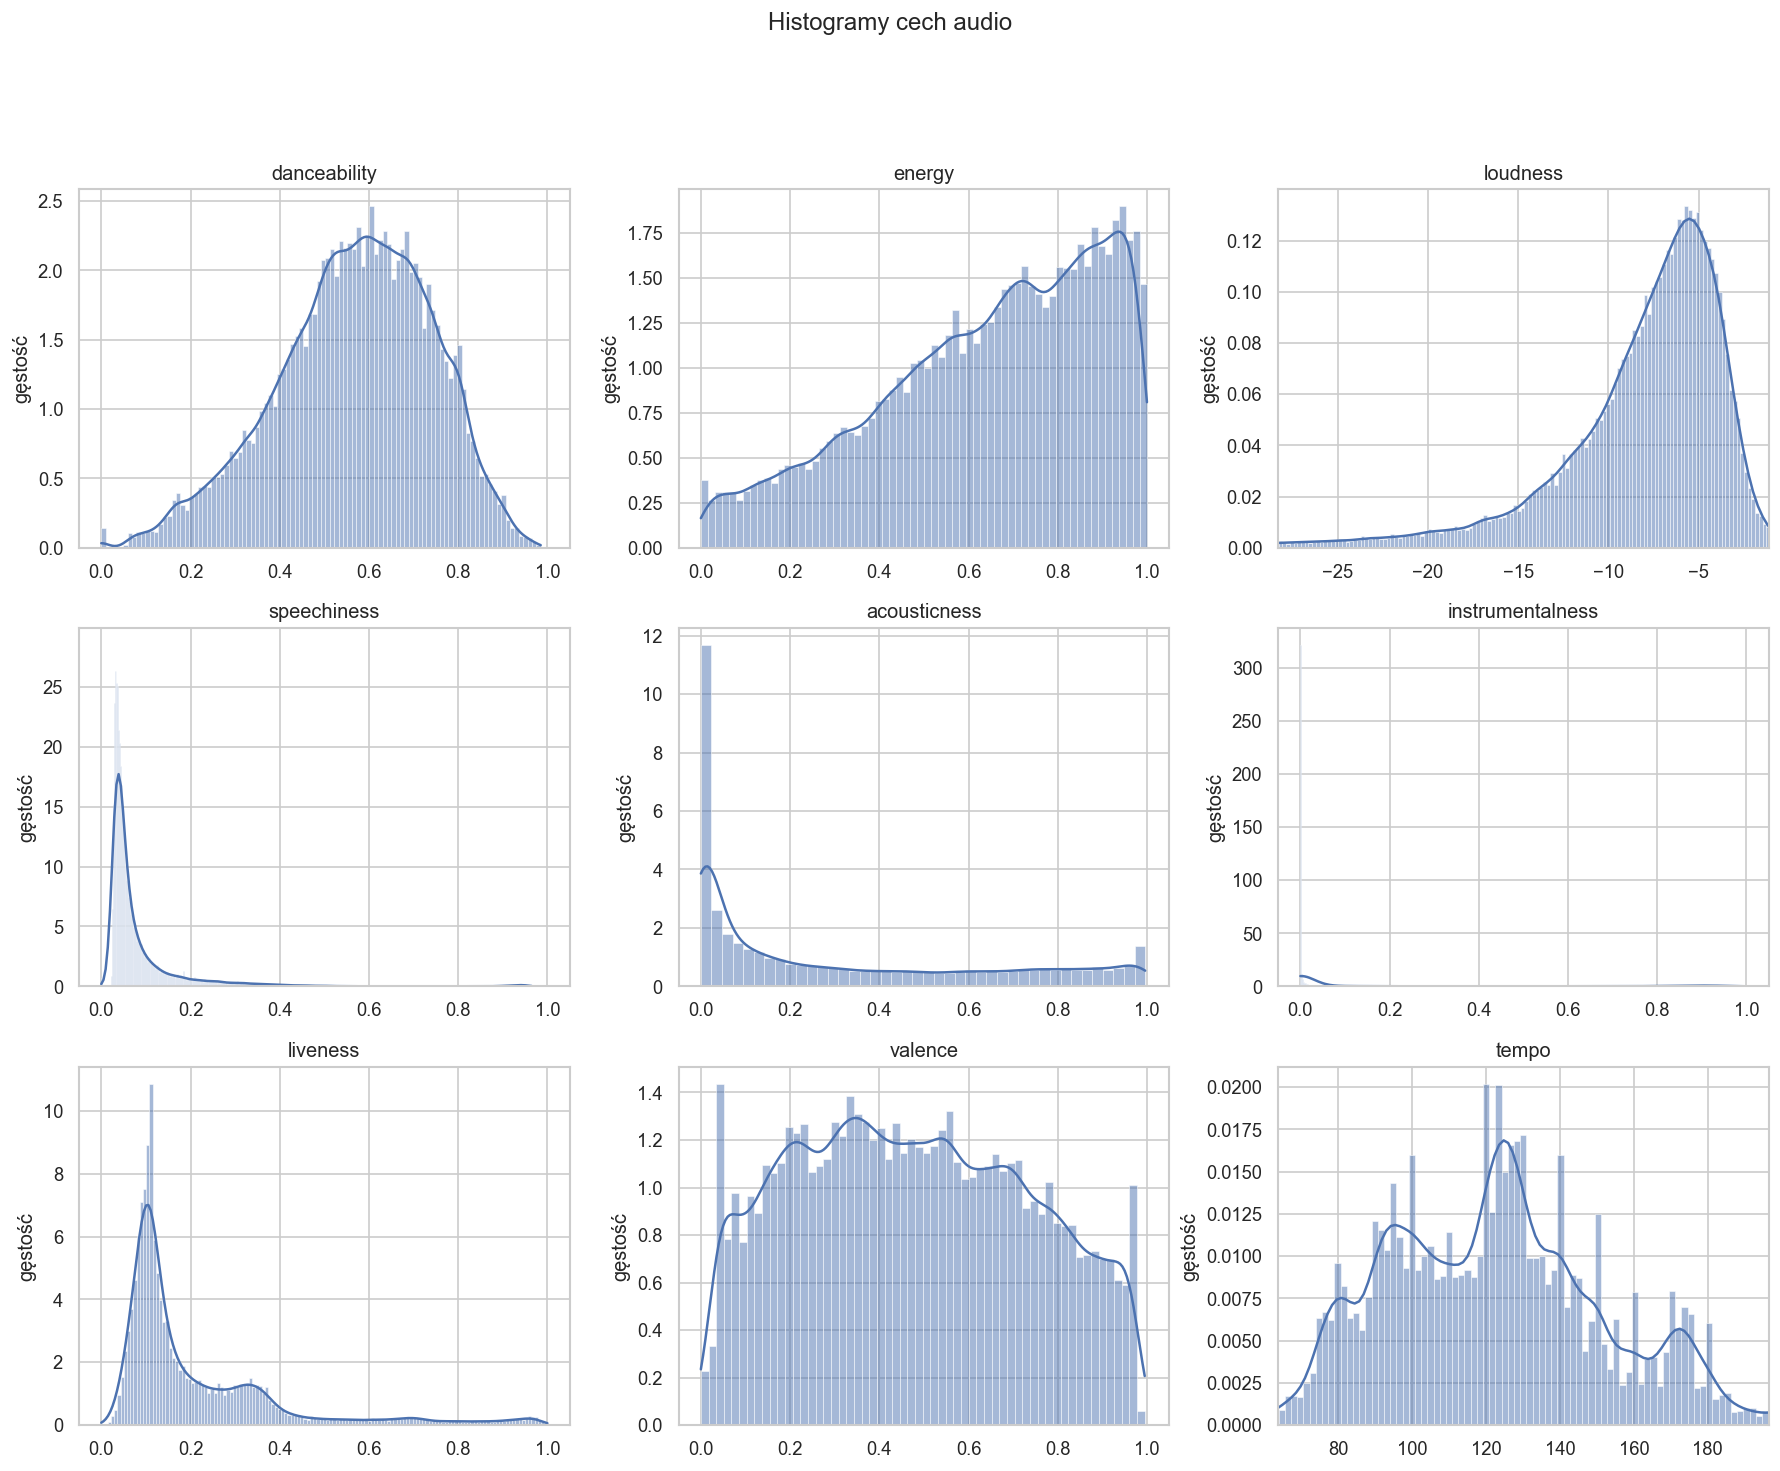

In [27]:
df_hist = df[features].copy()

bounded_01 = {
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
}

def xlim_1_99(col: str, s: pd.Series):
    if col in bounded_01:
        return (-0.05, 1.05)

    lo, hi = s.quantile([0.01, 0.99])

    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        return None

    pad = 0.02 * (hi - lo)
    return (lo - pad, hi + pad)


n = len(features)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, features):
    s = pd.to_numeric(df_hist[col], errors="coerce").dropna()

    if s.empty:
        ax.axis("off")
        continue

    sns.histplot(
        s,
        bins="fd",
        kde=True,
        stat="density",
        edgecolor="white",
        linewidth=0.3,
        ax=ax
    )

    lim = xlim_1_99(col, s)

    if lim:
        ax.set_xlim(lim)

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("gęstość")

for ax in axes[len(features):]:
    ax.axis("off")

fig.suptitle("Histogramy cech audio", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Rozkłady cech nie są równomierne – wiele z nich jest wyraźnie skośnych.
Cechy takie jak liveness, speechiness oraz instrumentalness mają większość wartości bliskich zeru, co oznacza, że dla dużej części utworów te właściwości są słabo zaznaczone.

Z kolei cechy takie jak valence i danceability mają bardziej rozłożone wartości, co sugeruje większą różnorodność utworów pod względem „nastroju” i „taneczności”.

Widoczny jest również szeroki zakres wartości dla tempo, co oznacza, że w zbiorze znajdują się zarówno wolne, jak i bardzo szybkie utwory.

## Analiza boxplotów i standaryzacja

Boxploty wykorzystano do oceny rozrzutu cech numerycznych oraz obecności potencjalnych wartości odstających. Ponieważ analizowane cechy mają różne skale i część z nich nie ma rozkładu zbliżonego do normalnego, przed porównaniem zastosowano odporną standaryzację `RobustScaler`.

`RobustScaler` przekształca dane względem mediany i rozstępu międzykwartylowego, dlatego jest mniej wrażliwy na wartości odstające niż klasyczna standaryzacja oparta na średniej i odchyleniu standardowym.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler

features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

features = [col for col in features if col in df.columns]

X = df[features].apply(pd.to_numeric, errors="coerce").dropna()

X.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
danceability,114000.0,0.567,0.174,0.000,0.456,0.580,0.695,0.985
energy,114000.0,0.641,0.252,0.000,0.472,0.685,0.854,1.000
loudness,114000.0,-8.259,5.029,-49.531,-10.013,-7.004,-5.003,4.532
speechiness,114000.0,0.085,0.106,0.000,0.036,0.049,0.084,0.965
acousticness,114000.0,0.315,0.333,0.000,0.017,0.169,0.598,0.996
instrumentalness,114000.0,0.156,0.310,0.000,0.000,0.000,0.049,1.000
liveness,114000.0,0.214,0.190,0.000,0.098,0.132,0.273,1.000
valence,114000.0,0.474,0.259,0.000,0.260,0.464,0.683,0.995
tempo,114000.0,122.148,29.978,0.000,99.219,122.017,140.071,243.372


Statystyki opisowe pokazują, że cechy różnią się zakresem wartości i skalą pomiaru. Z tego powodu bezpośrednie porównanie ich na jednym boxplocie byłoby mało czytelne. Dodatkowo obecność skośnych rozkładów i potencjalnych wartości odstających uzasadnia zastosowanie odpornej standaryzacji.

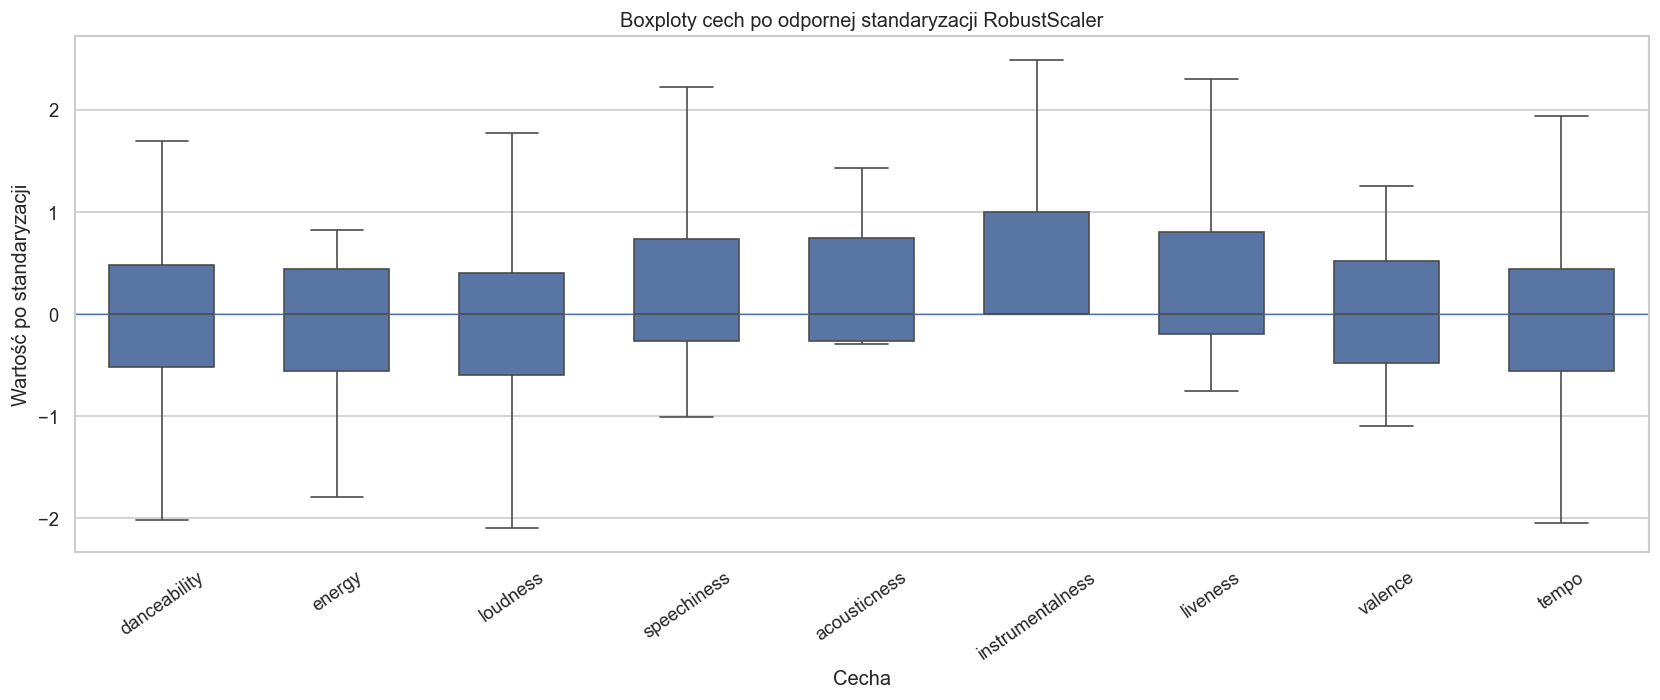

In [29]:
scaler = RobustScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=features,
    index=X.index
)

long_scaled = X_scaled.melt(
    var_name="cecha",
    value_name="wartość po standaryzacji"
)

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=long_scaled,
    x="cecha",
    y="wartość po standaryzacji",
    showfliers=False,
    width=0.6,
    linewidth=1
)

plt.axhline(0, linewidth=0.8)
plt.title("Boxploty cech po odpornej standaryzacji RobustScaler")
plt.xlabel("Cecha")
plt.ylabel("Wartość po standaryzacji")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

Po zastosowaniu `RobustScaler` wszystkie cechy zostały sprowadzone do porównywalnej skali, gdzie wartość 0 odpowiada medianie danej cechy. Dzięki temu można porównywać rozrzut zmiennych na jednym wykresie bez dominacji cech mierzonych w większych jednostkach.

Różnice w szerokości pudełek wskazują, które cechy mają większe lub mniejsze zróżnicowanie wśród typowych obserwacji. Ukrycie pojedynczych wartości odstających pozwala skupić interpretację na głównej części rozkładu.

### Korelacja

Analiza korelacji pozwala sprawdzić zależności między cechami.

- **Pearson** – mierzy zależność liniową między zmiennymi  
- **Spearman** – opiera się na rangach i jest bardziej odporny na wartości odstające  

Dla lepszej czytelności pokazano tylko dolną część macierzy korelacji.

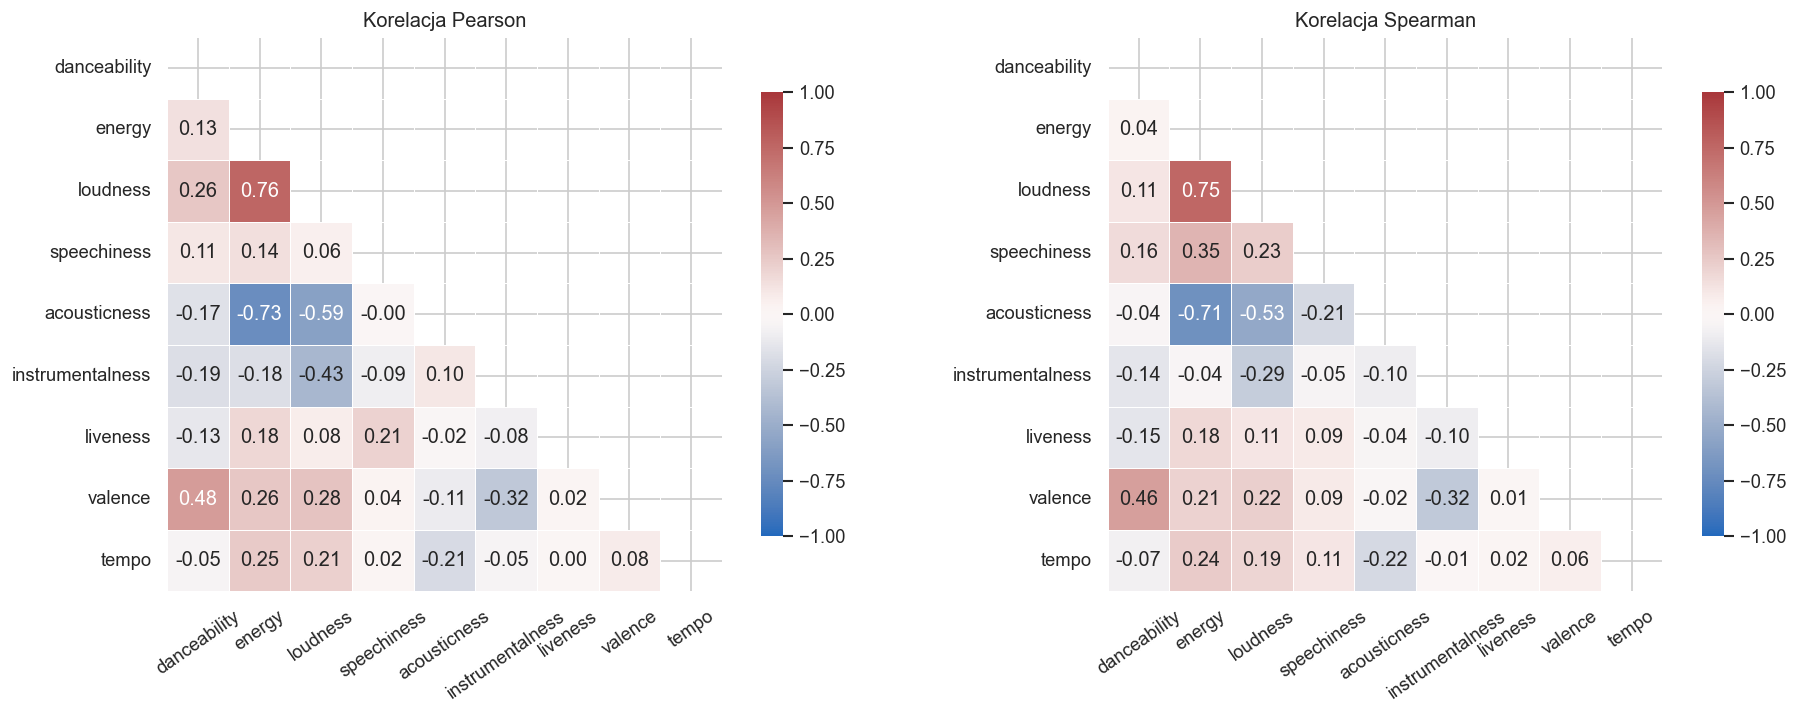

In [30]:
corr_p = df[features].corr(method="pearson")
corr_s = df[features].corr(method="spearman")

mask = np.triu(np.ones_like(corr_p, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, corr, title in [
    (axes[0], corr_p, "Korelacja Pearson"),
    (axes[1], corr_s, "Korelacja Spearman"),
]:
    sns.heatmap(
        corr,
        mask=mask,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.4,
        annot=True,
        fmt=".2f",
        cbar_kws={"shrink": 0.8},
        ax=ax,
    )
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


Na podstawie macierzy korelacji widać, że istnieją wyraźne zależności między niektórymi cechami.

Najsilniejszą dodatnią korelację obserwujemy między energy i loudness, co oznacza, że bardziej energetyczne utwory są zazwyczaj głośniejsze.

Z kolei acousticness jest ujemnie skorelowane z energy, co sugeruje, że utwory akustyczne są zazwyczaj mniej energetyczne.

Różnice między korelacją Pearsona i Spearmana są niewielkie, co wskazuje, że zależności między cechami są w dużej mierze liniowe.

### Pairplot

Pairplot pozwala zobaczyć zależności między parami cech oraz ich rozkłady.

Ze względu na dużą liczbę danych, wykres został wykonany na losowej próbce.

Na wykresie można zaobserwować:
- zależności między cechami (np. energy i loudness),
- kształt rozkładów na przekątnej,
- ewentualne różnice między utworami (np. explicit vs non-explicit).


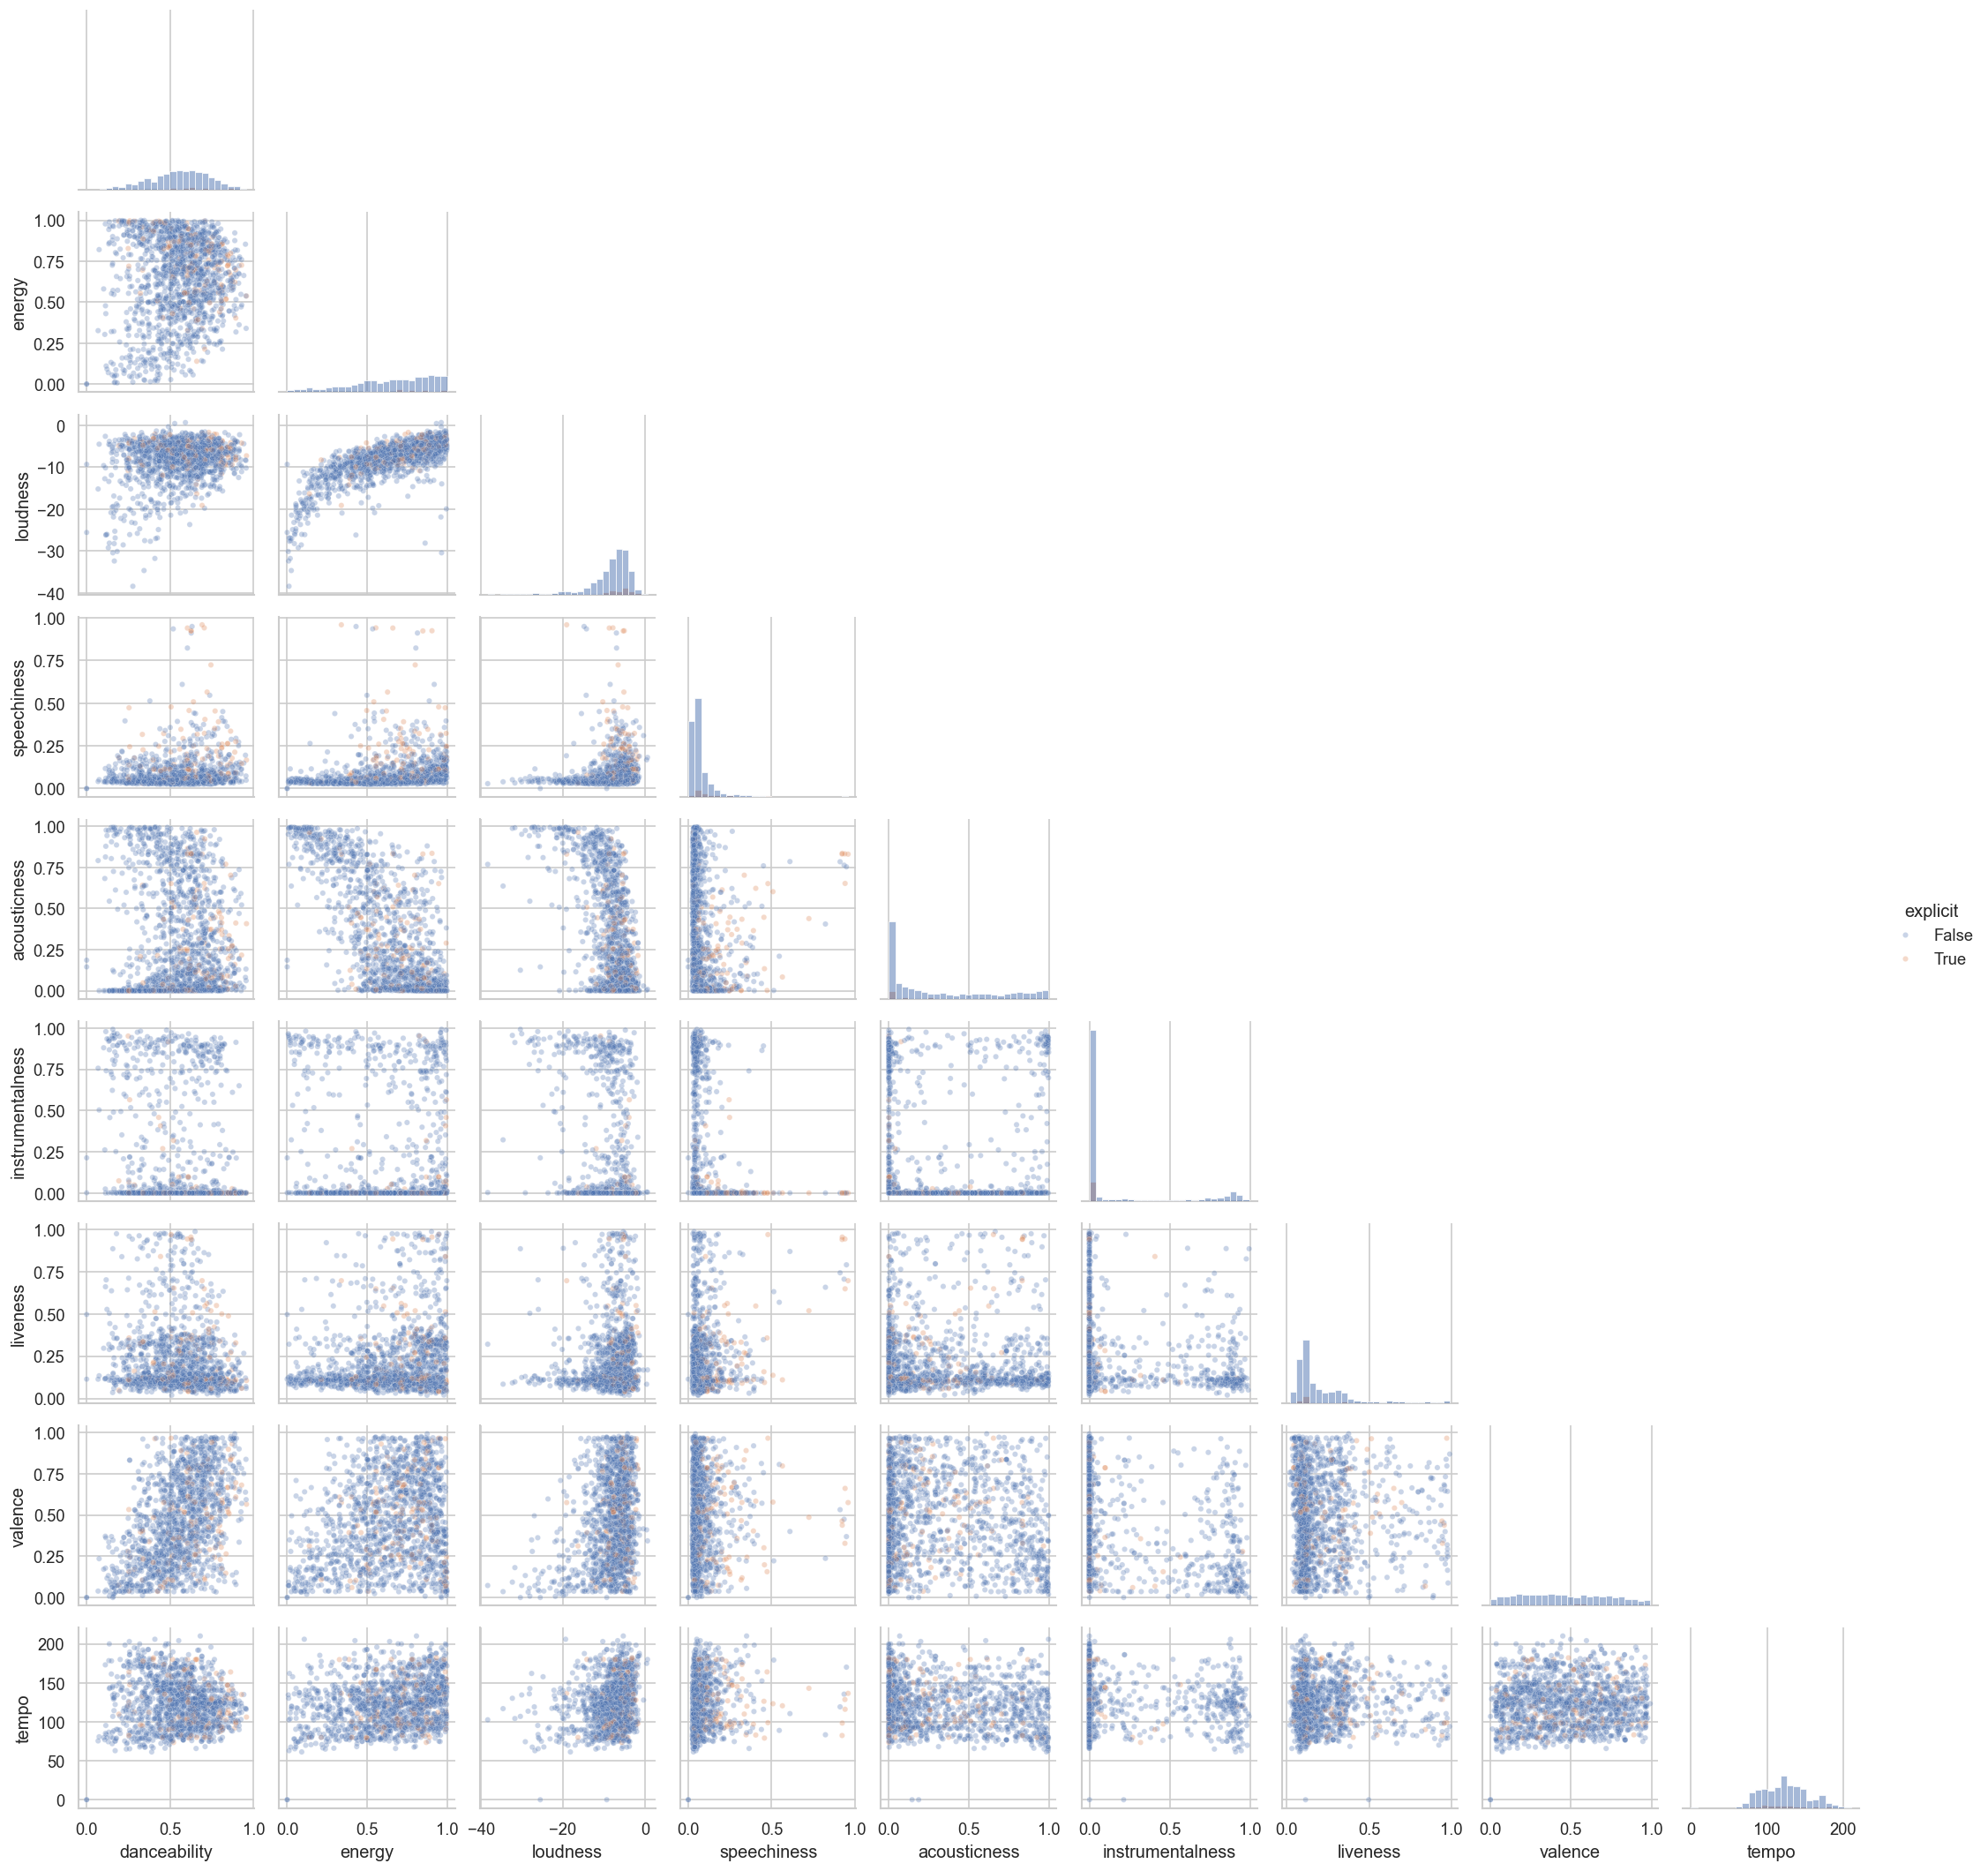

In [31]:
pair_cols = features

plot_cols = pair_cols.copy()
if "explicit" in df.columns:
    plot_cols.append("explicit")

sample = df[plot_cols].dropna().sample(
    min(1500, len(df)),
    random_state=42,
)

sns.pairplot(
    sample,
    vars=pair_cols,
    hue="explicit" if "explicit" in sample.columns else None,
    corner=True,
    diag_kind="hist",
    height=2.0,
    plot_kws={"alpha": 0.3, "s": 14},
    diag_kws={"bins": 25},
)

plt.show()

### Wnioski (krótko)

- Zbiór jest duży (~114 tys. utworów) i ma spójne cechy audio, więc dobrze pasuje do podejścia content-based.
- Braki danych są minimalne (pojedyncze w polach tekstowych), więc nie trzeba agresywnego czyszczenia.
- Rozkłady części cech są skośne i mają długie ogony (np. `tempo`, `instrumentalness`) — dlatego w EDA warto patrzeć na percentyle, a w modelu stosować skalowanie.
- Najsilniejsze zależności między cechami audio to zwykle `energy`–`loudness` (dodatnio) oraz `energy`–`acousticness` (ujemnie), co widać też na pairplocie.
- `popularity` ma raczej słabe związki z samymi cechami audio, więc lepiej traktować je jako metadane/target do osobnej analizy, a nie główną podstawę rekomendacji.
- `explicit` zwykle nie rozdziela wyraźnie „chmur” punktów dla cech audio (różnice są subtelne).
- `track_genre` ma dużo kategorii i rozkład jest nierówny — do wykresów warto brać Top N, a do rekomendacji rozważyć kodowanie gatunku (np. one-hot).
- Pod rekomendacje: standaryzacja cech audio + podobieństwo cosinusowe działa jako sensowny baseline (w notebooku liczone na próbie ze względów pamięciowych).
